Julia Hughes

# Solidworks Validation: Custom Material Properties

**Analyzes tensile test data to calculate material properties (Elastic Modulus, Shear Modulus, Tensile Strength, Yield Strength) and visualize stress-strain behavior for creating a custom material model.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files
import io

# Step 1: Upload the data file
uploaded = files.upload()

# Step 2: Load data from the uploaded file into a numpy array
data_file = list(uploaded.keys())[0]  # Use the first uploaded file
data = np.genfromtxt(io.BytesIO(uploaded[data_file]), delimiter=',', skip_header=1)

# Extract relevant data (columns for displacement and force)
displacement_mm = data[:, 4]  # Column 5: Displacement (in mm)
force_N = data[:, 5]  # Column 6: Force (in N)

# Initial dimensions for the sample
width = 2  # mm
base = 2  # mm
length = 15  # mm (region of uniform deformation)
cross_sectional_area = width * base  # mm²

# Step 3: Calculate stress and strain
strain = displacement_mm / length  # Strain (dimensionless)
stress = force_N / cross_sectional_area  # Stress in MPa (N/mm²)

# Plot Stress-Strain Curve
plt.figure(figsize=(8, 6))
plt.plot(strain, stress, label="Stress-Strain Curve", color='green')
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Stress-Strain Curve')
plt.grid(True)
plt.legend()
plt.show()

# Step 4: Calculate Material Properties

## (a) Elastic Modulus (Young's Modulus)
# Assume the linear region is between indices 1 and 4
linear_start, linear_end = 1, 5
lin_reg_stress = stress[linear_start:linear_end]
lin_reg_strain = strain[linear_start:linear_end]

# Perform linear regression on the linear region
slope, intercept, r_value, p_value, std_err = stats.linregress(lin_reg_strain, lin_reg_stress)
elastic_modulus = round(slope, 2)  # Elastic Modulus (MPa)
print("Elastic Modulus (Young's Modulus): ", elastic_modulus, " MPa")

## (b) Shear Modulus
poissons_ratio = 0.35  # Assumed Poisson's ratio
shear_modulus = round(elastic_modulus / (2 * (1 + poissons_ratio)), 2)  # MPa
print("Shear Modulus: ", shear_modulus, " MPa")

## (c) Tensile Strength (Ultimate Stress)
max_force = max(force_N)
tensile_strength = round(max_force / cross_sectional_area, 2)  # MPa
print("Tensile Strength: ", tensile_strength, " MPa")

## (d) Yield Strength (0.2% Offset Method)
offset_strain = 0.002  # 0.2% offset
offset_line = elastic_modulus * (strain - offset_strain)  # Offset line

# Find where the stress-strain curve intersects the offset line
yield_index = np.where(stress >= offset_line)[0][0]
yield_strength = round(stress[yield_index], 2)  # MPa
print("Yield Strength: ", yield_strength, " MPa")

# Step 5: Plot Offset Line and Stress-Strain Curve
plt.figure(figsize=(8, 6))
plt.plot(strain, stress, label="Stress-Strain Curve", color='green')
plt.plot(strain, offset_line, '--', label="0.2% Offset Line", color='red')
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Stress-Strain Curve with 0.2% Offset Line')
plt.grid(True)
plt.legend()
plt.show()



# Solidworks Validation: Torsion

**Hand Calculations**

In [ ]:
import numpy as np

# Given values
radius = 6  # mm (cylinder radius)
length = 140  # mm (cylinder length)
torque = 1  # N·m (applied torque)
shear_modulus = 316 * 1e6  # Pa (Shear Modulus in N/m²)

# Convert units to consistent SI units
radius_m = radius / 1000  # Convert mm to meters
length_m = length / 1000  # Convert mm to meters

# Step 1: Polar Moment of Inertia (J) for a solid cylinder
J = (np.pi * radius_m**4) / 2  # m^4
print(f"Polar Moment of Inertia (J): {J:.2e} m^4")

# Step 2: Maximum Shear Stress (τ_max)
max_shear_stress = torque * radius_m / J  # Pa
print(f"Maximum Shear Stress (τ_max): {max_shear_stress:.2f} Pa (or {max_shear_stress / 1e6:.2f} MPa)")

# Step 3: Von Mises Stress
von_mises_stress = np.sqrt(3) * max_shear_stress  # Pa
print(f"Von Mises Stress: {von_mises_stress:.2f} Pa (or {von_mises_stress / 1e6:.2f} MPa)")

# Step 4: Angular Displacement (θ) in radians
angular_displacement = (torque * length_m) / (shear_modulus * J)  # radians
print(f"Angular Displacement: {angular_displacement:.6f} radians")

# Step 5: Tangential Displacement (δ_tan) in mm
tangential_displacement = angular_displacement * radius_m * 1000  # Convert to mm
print(f"Tangential Displacement: {tangential_displacement:.3f} mm")

# Step 6: Resultant Displacement (for pure torsion)
resultant_displacement = tangential_displacement
print(f"Resultant Displacement: {resultant_displacement:.3f} mm")


Polar Moment of Inertia (J): 2.04e-09 m^4
Maximum Shear Stress (τ_max): 2947313.76 Pa (or 2.95 MPa)
Von Mises Stress: 5104897.18 Pa (or 5.10 MPa)
Angular Displacement: 0.217629 radians
Tangential Displacement: 1.306 mm
Resultant Displacement: 1.306 mm


**Fig.1: FEA Analysis of Standard Model**

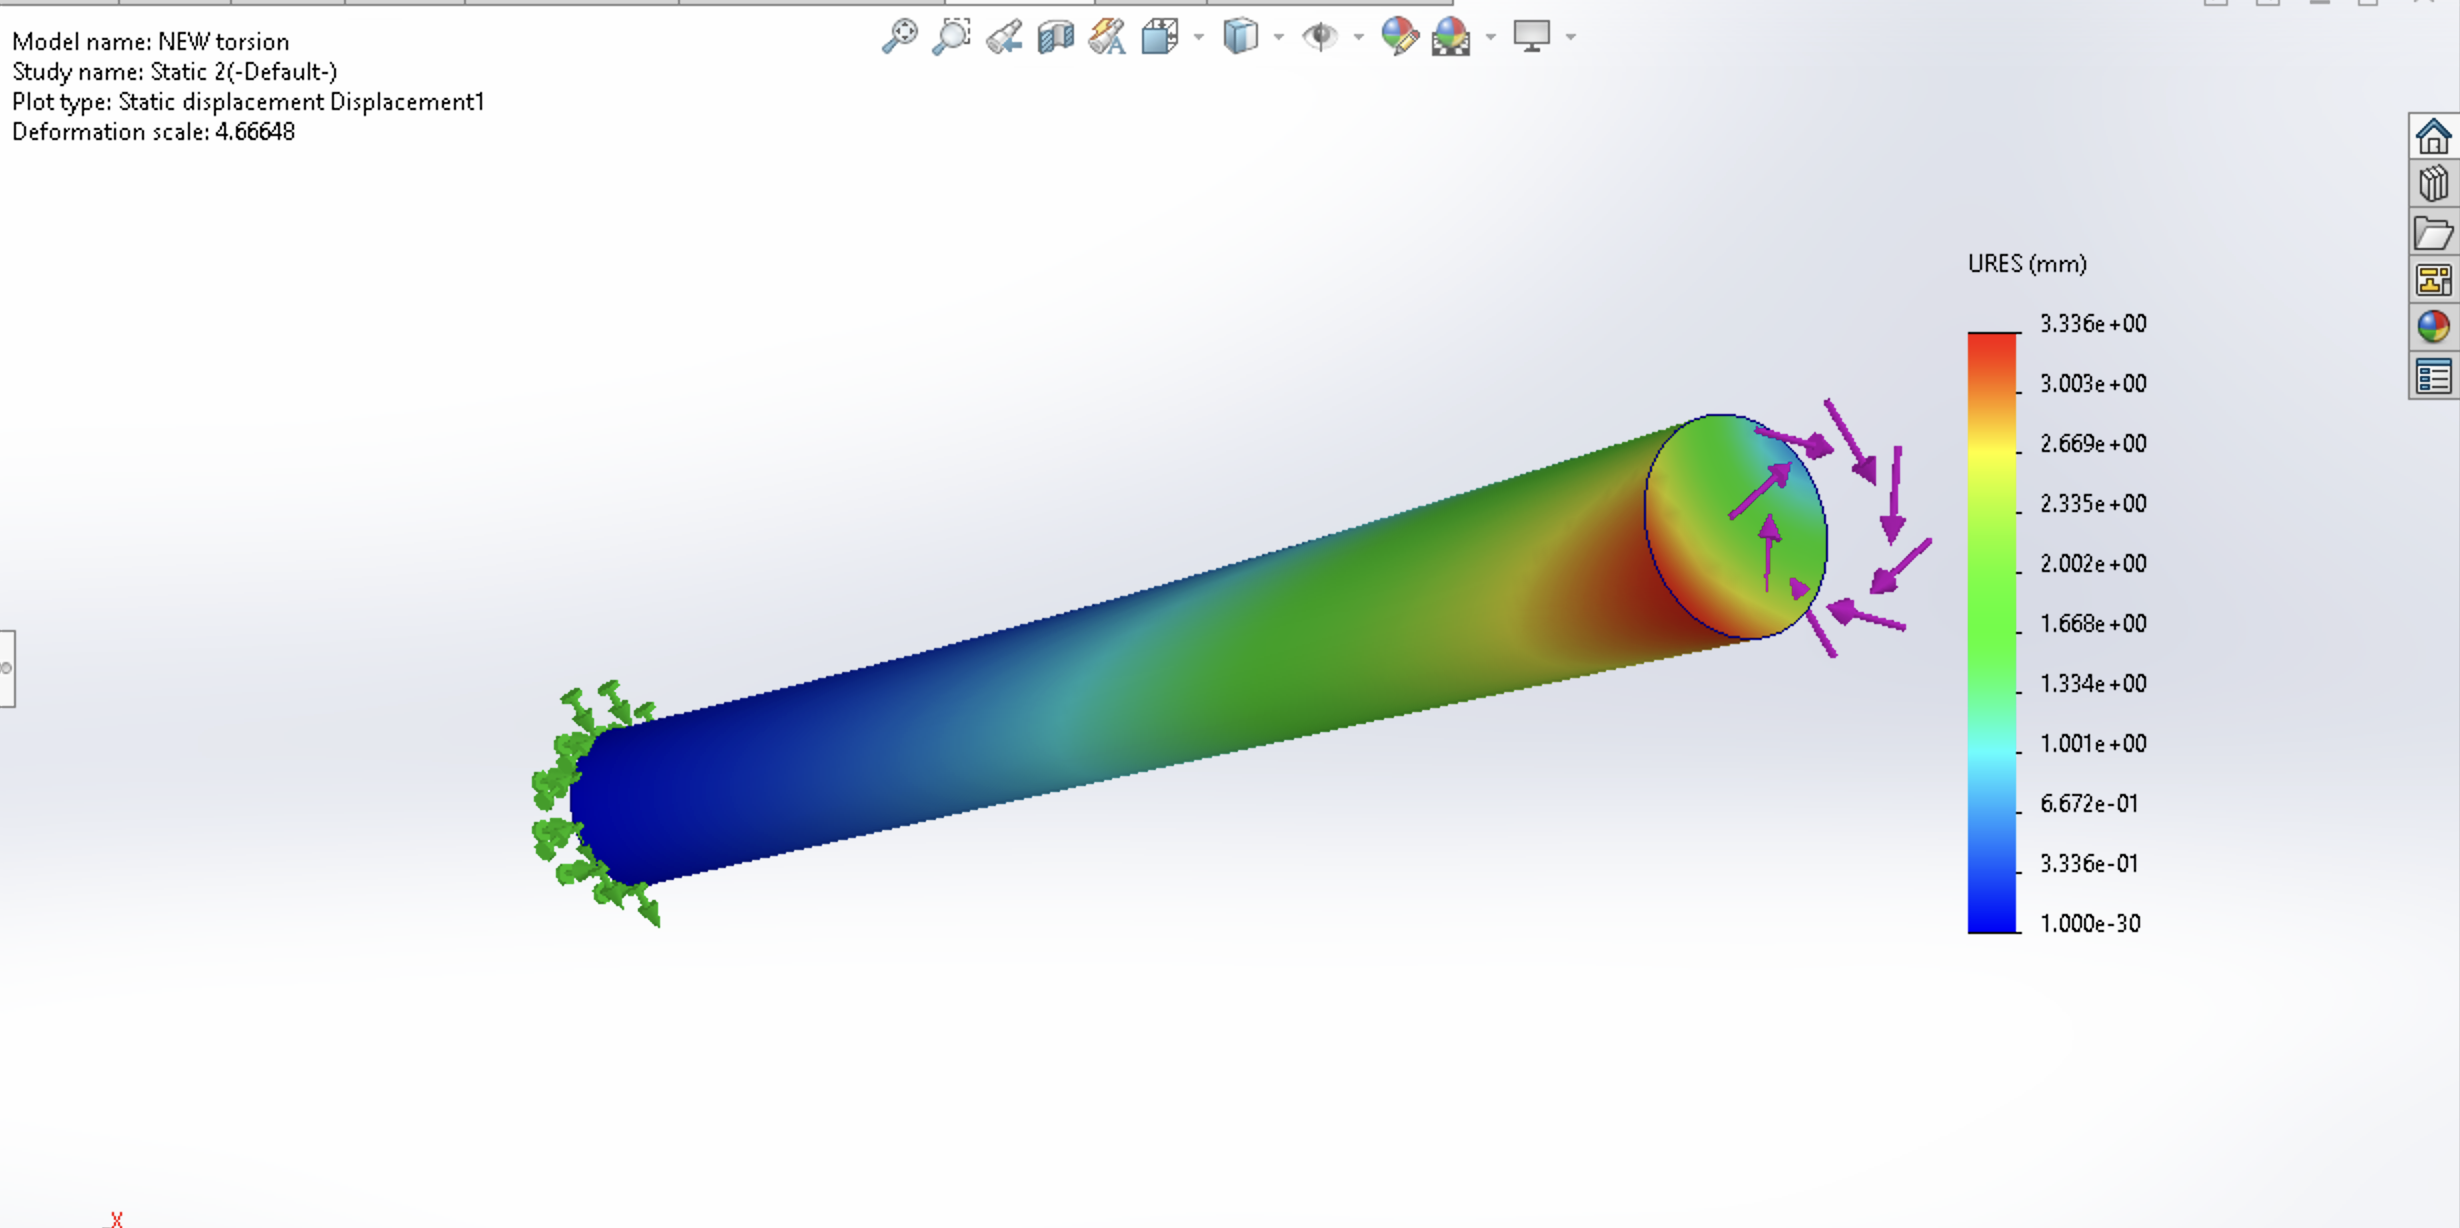



---



# Solidworks Validation: 3 Point Bending

**Hand Calculations**

In [ ]:
# Inputs
beam_length = 140  # mm (length of the beam)
force = 1  # N (concentrated load in the middle of the beam)
height = 15  # mm (beam height)
width = 12  # mm (beam width)

# Calculating reactions at supports (for symmetry, as force is applied in the center)
Ay = force / 2  # Reaction at fixed support (vertical force)
By = force / 2  # Reaction at roller support (vertical force)
Ax = 0  # Reaction at fixed support (horizontal force)

# Moment of inertia (I) for a rectangular cross-section
beam_MOI = (width * height**3) / 12  # mm^4

# Maximum bending moment occurs at the center
# maxMoment = Ay * (beam_length / 2)
maxMoment = By * (beam_length / 2)  # N·mm

# Distance from the neutral axis to the outermost fiber (c = h/2)
c = height / 2  # mm

# Concentrated bending stress
concentrated_bending_stress = (maxMoment * c) / beam_MOI  # N/mm^2 or MPa

# Output the results
print(f"Beam Length: {beam_length} mm")
print(f"Applied Force: {force} N")
print(f"Reactions: Ay = {Ay} N, By = {By} N, Ax = {Ax} N")
print(f"Moment of Inertia (MOI): {beam_MOI:.2f} mm^4")
print(f"Maximum Bending Moment: {maxMoment:.2f} N·mm")
print(f"Concentrated Bending Stress: {concentrated_bending_stress:.3f} MPa")


Beam Length: 140 mm
Applied Force: 1 N
Reactions: Ay = 0.5 N, By = 0.5 N, Ax = 0 N
Moment of Inertia (MOI): 3375.00 mm^4
Maximum Bending Moment: 35.00 N·mm
Concentrated Bending Stress: 0.078 MPa


**Fig.2: FEA Analysis of Standard Model Beam**

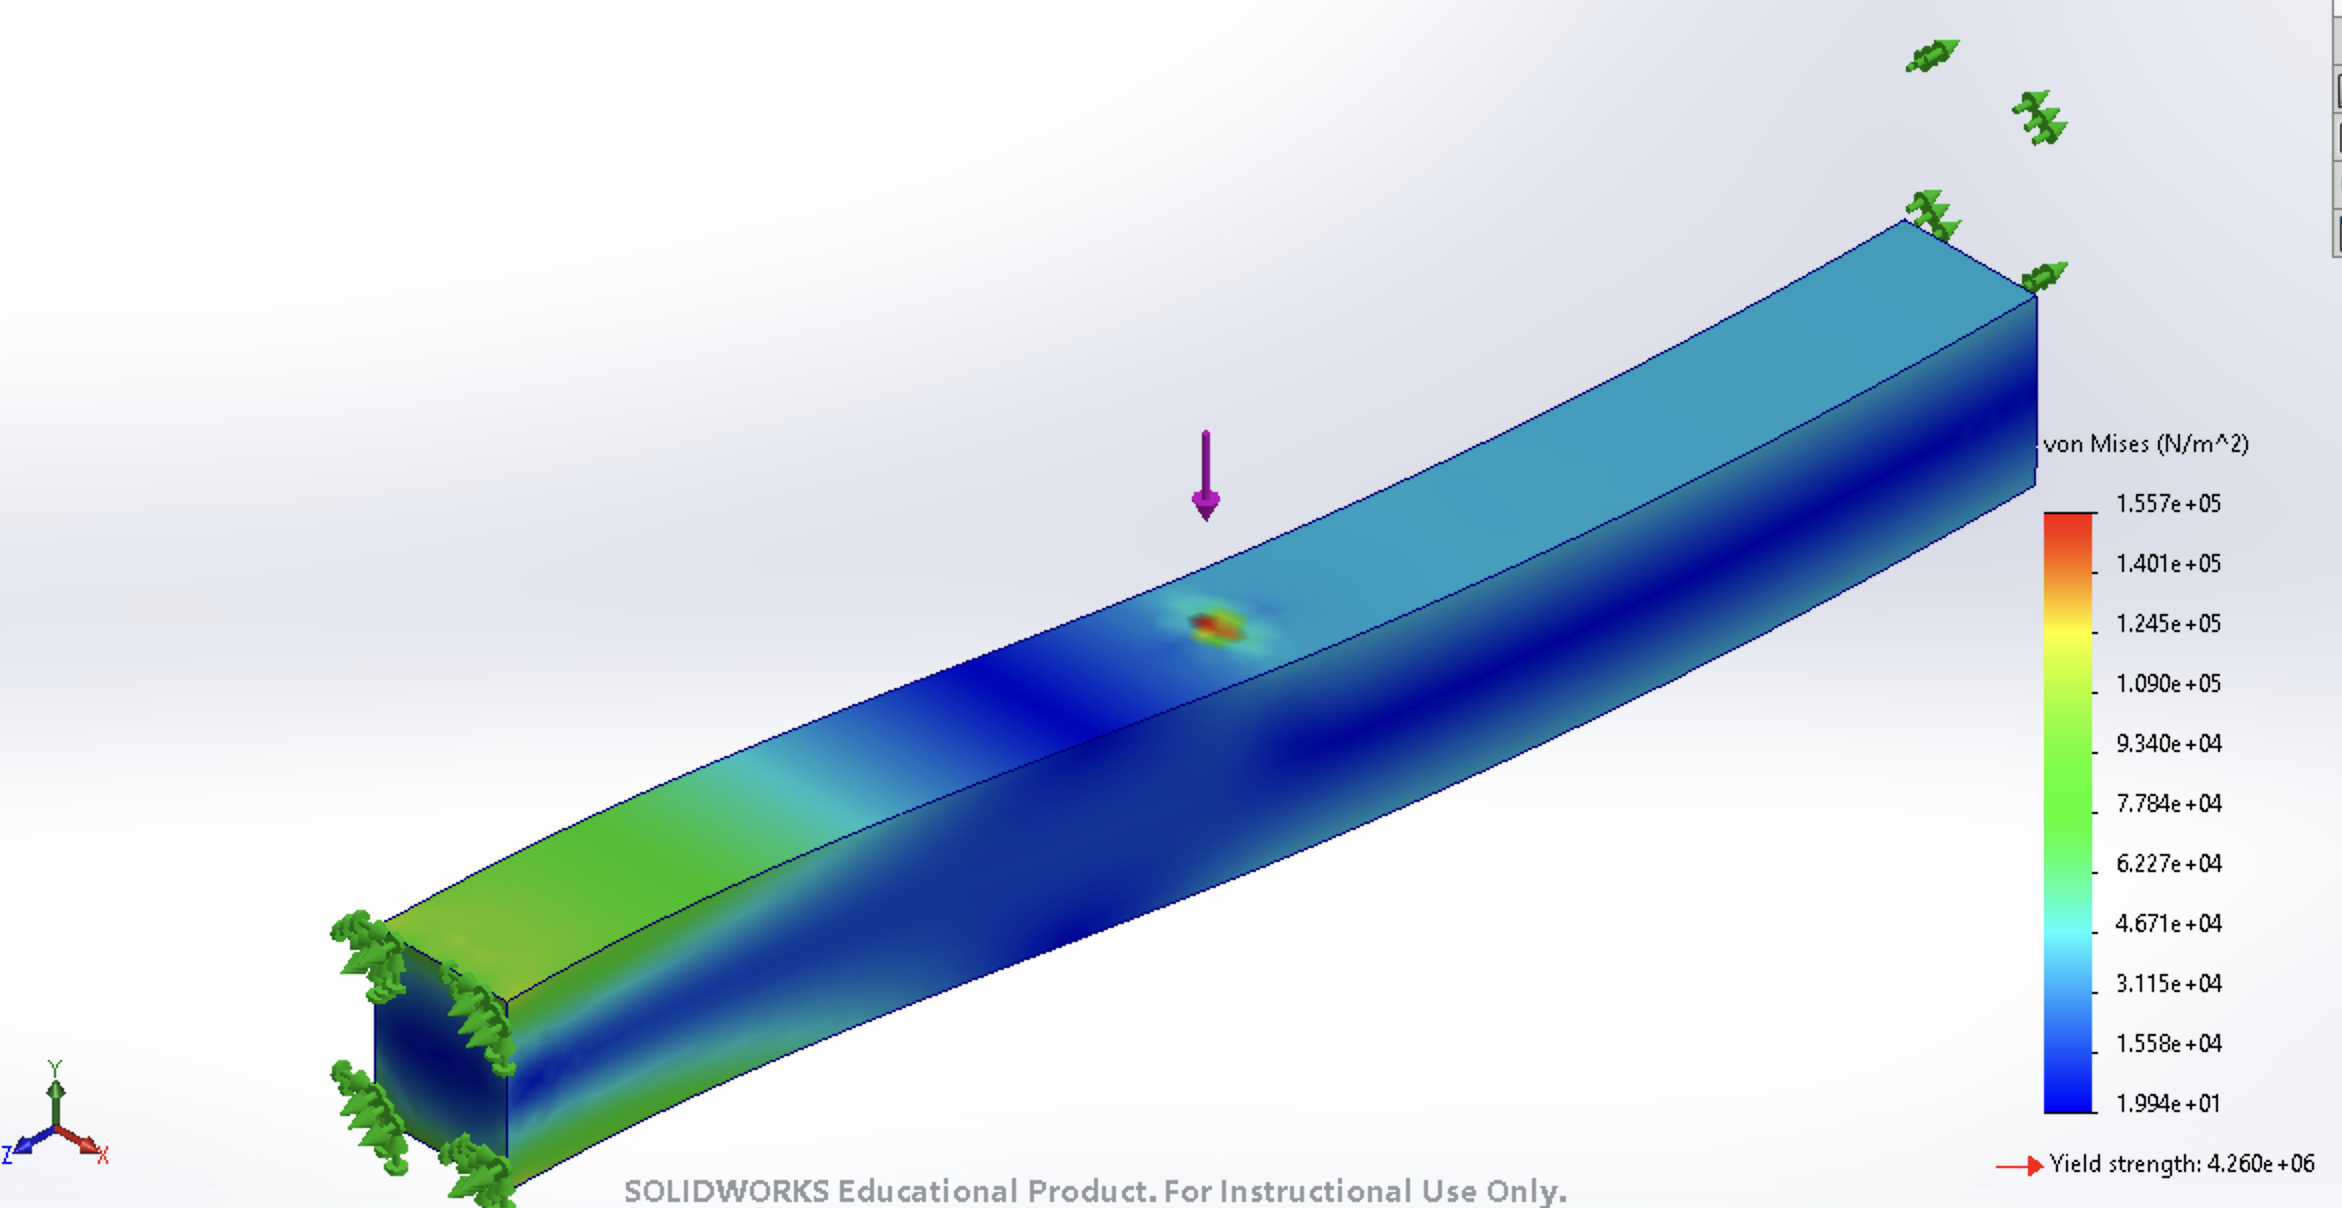



---



## Hand Calculations vs Solidworks FEA % Difference

**This code validates the accuracy of Finite Element Analysis (FEA) results by comparing them to hand calculations for bending stress and torsional displacement, calculating percent differences, and presenting the results in table format.**

In [ ]:
# Function to calculate percent difference
def percentDifference(value1, value2):
    """
    Calculate the percent difference between two values.
    Formula: |value1 - value2| / [(value1 + value2) / 2] * 100
    """
    return abs(value1 - value2) / ((value1 + value2) / 2) * 100

# Section A: Validation

# 3-Point Bending (Bending Stress)
FEA_BendingStress = 0.079  # Maximum bending stress from FEA (MPa)
HandCalc_BendingStress = 0.078  # Maximum bending stress from hand calculations (MPa)

# Torsion (Angle and Displacement)
FEA_TorsionAngle = 0.2449  # Angle of torsion from FEA (radians)
FEA_TorsionDisplacement = 1.662  # Torsional displacement from FEA (mm)
HandCalc_TorsionAngle = 0.217629  # Angle of torsion from hand calculations (radians, no difference)
HandCalc_TorsionDisplacement = 1.306  # Torsional displacement from hand calculations (mm)

# Calculate Percent Differences
bendingStressPercentDiff = round(percentDifference(FEA_BendingStress, HandCalc_BendingStress), 2)
torsionDisplacementPercentDiff = round(percentDifference(FEA_TorsionDisplacement, HandCalc_TorsionDisplacement), 2)

# Display Results in Table Format
print("Validation Results (Table Format):\n")
print(f"{'Parameter':<30} {'FEA Value':<15} {'Hand Calculated':<20} {'Percent Difference (%)':<10}")
print("-" * 75)
print(f"{'Bending Stress (MPa)':<30} {FEA_BendingStress:<15} {HandCalc_BendingStress:<20} {bendingStressPercentDiff:<10}")
print(f"{'Torsional Displacement (mm)':<30} {FEA_TorsionDisplacement:<15} {HandCalc_TorsionDisplacement:<20} {torsionDisplacementPercentDiff:<10}")
print(f"{'Angle of Torsion (rad)':<30} {FEA_TorsionAngle:<15} {HandCalc_TorsionAngle:<20} {'0.00':<10}")  # No difference



Validation Results (Table Format):

Parameter                      FEA Value       Hand Calculated      Percent Difference (%)
---------------------------------------------------------------------------
Bending Stress (MPa)           0.079           0.078                1.27      
Torsional Displacement (mm)    1.662           1.306                23.99     
Angle of Torsion (rad)         0.2449          0.217629             0.00      




---



# Simplified Prosthetic Foot

**Fig 3. Initial Foot Part**
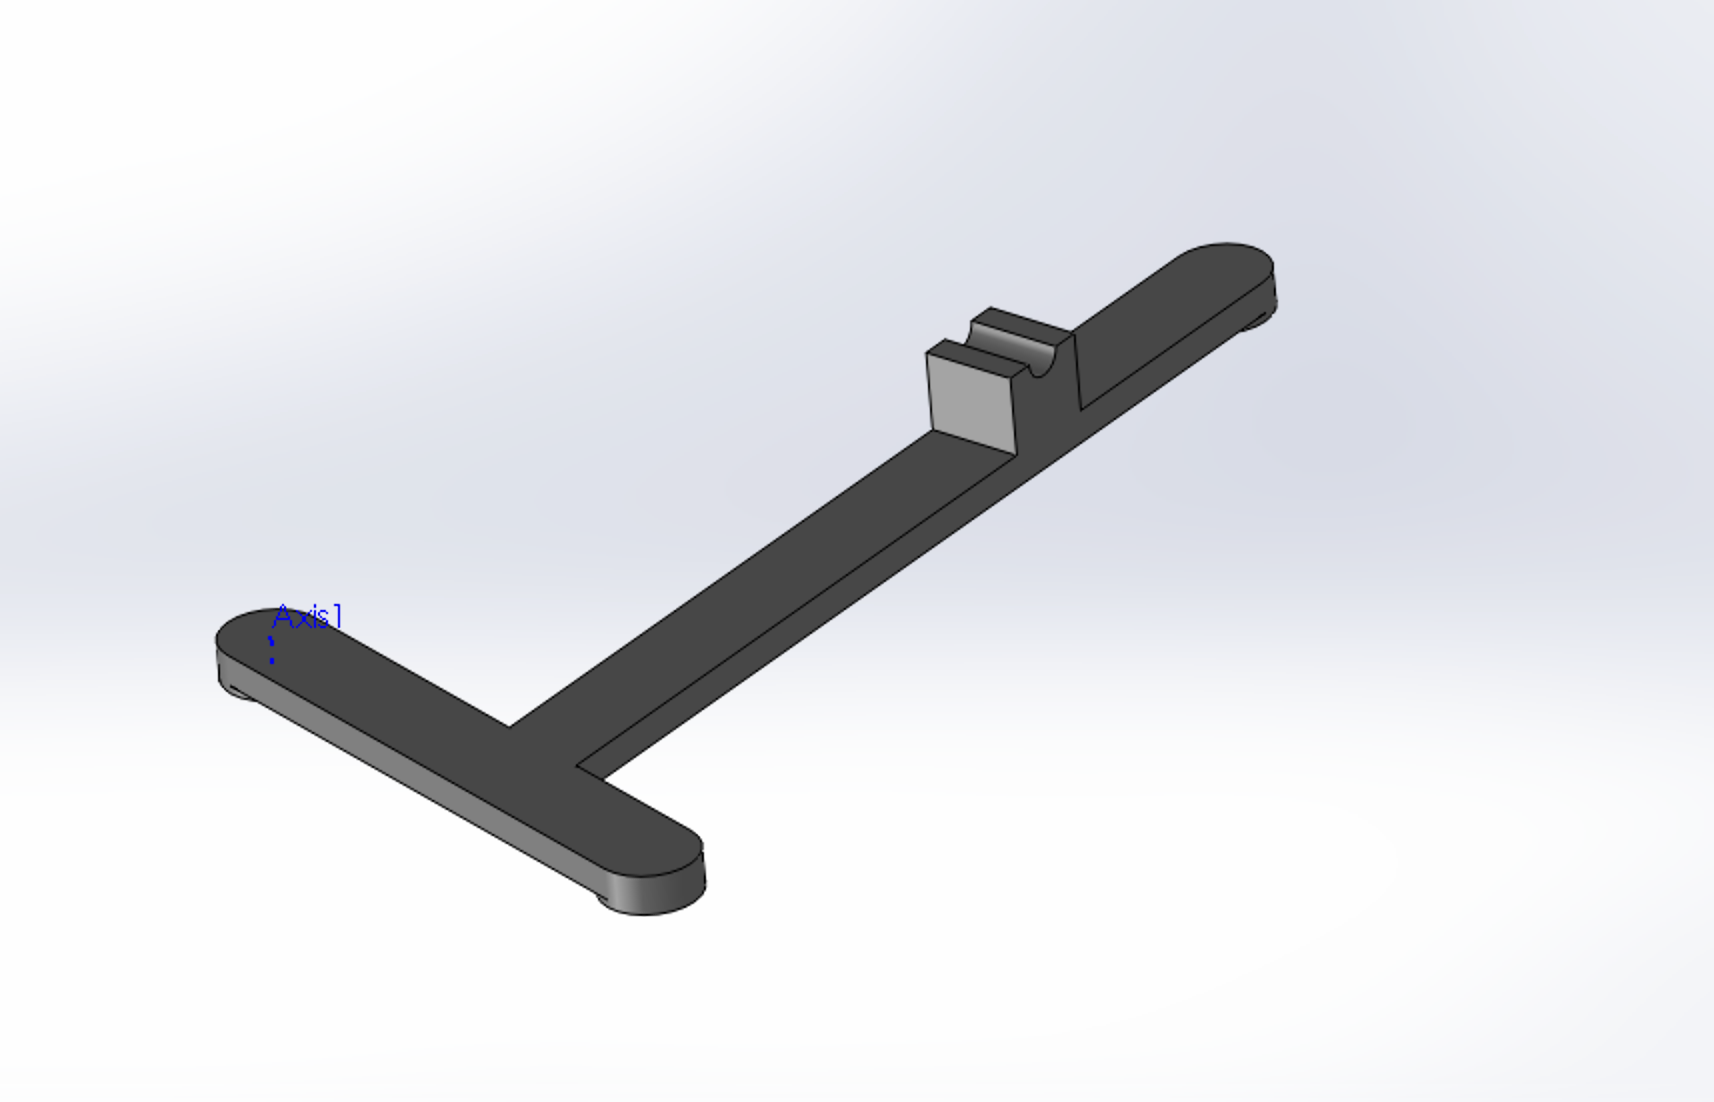

**Fig 4: Initial FEA Analysis of Model**
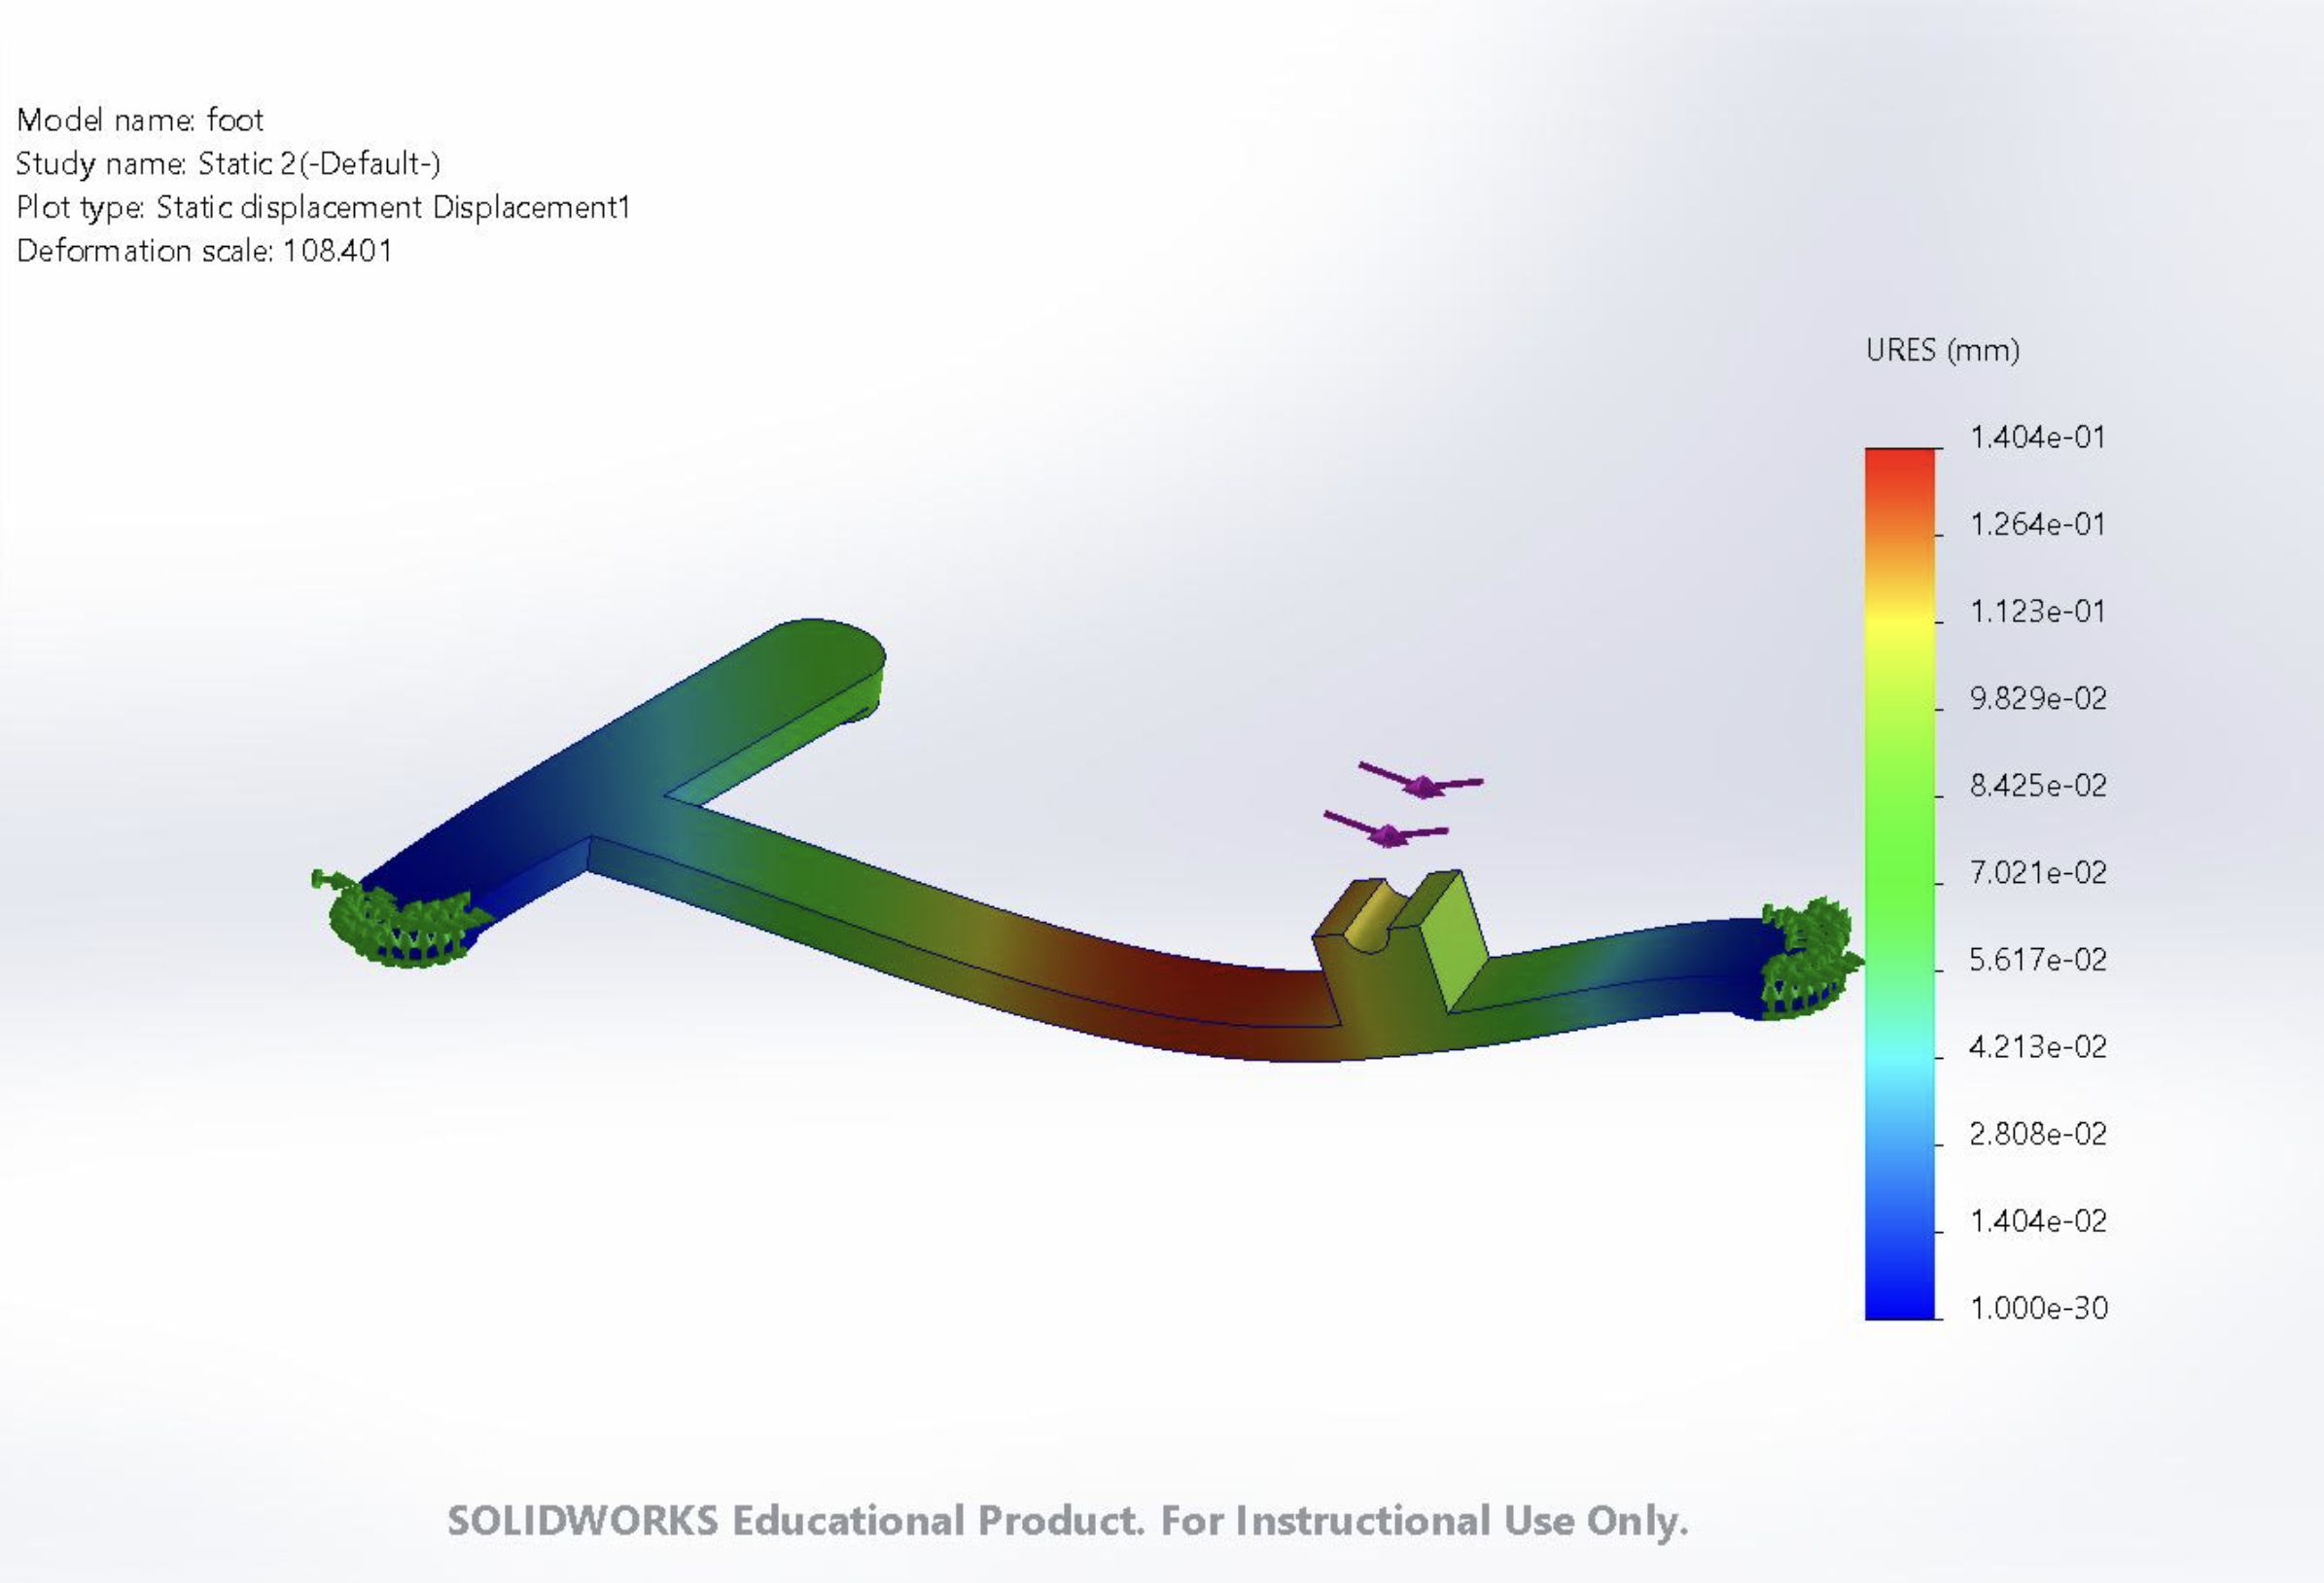



---



**Fig. 5: Optimized Model of Foot**
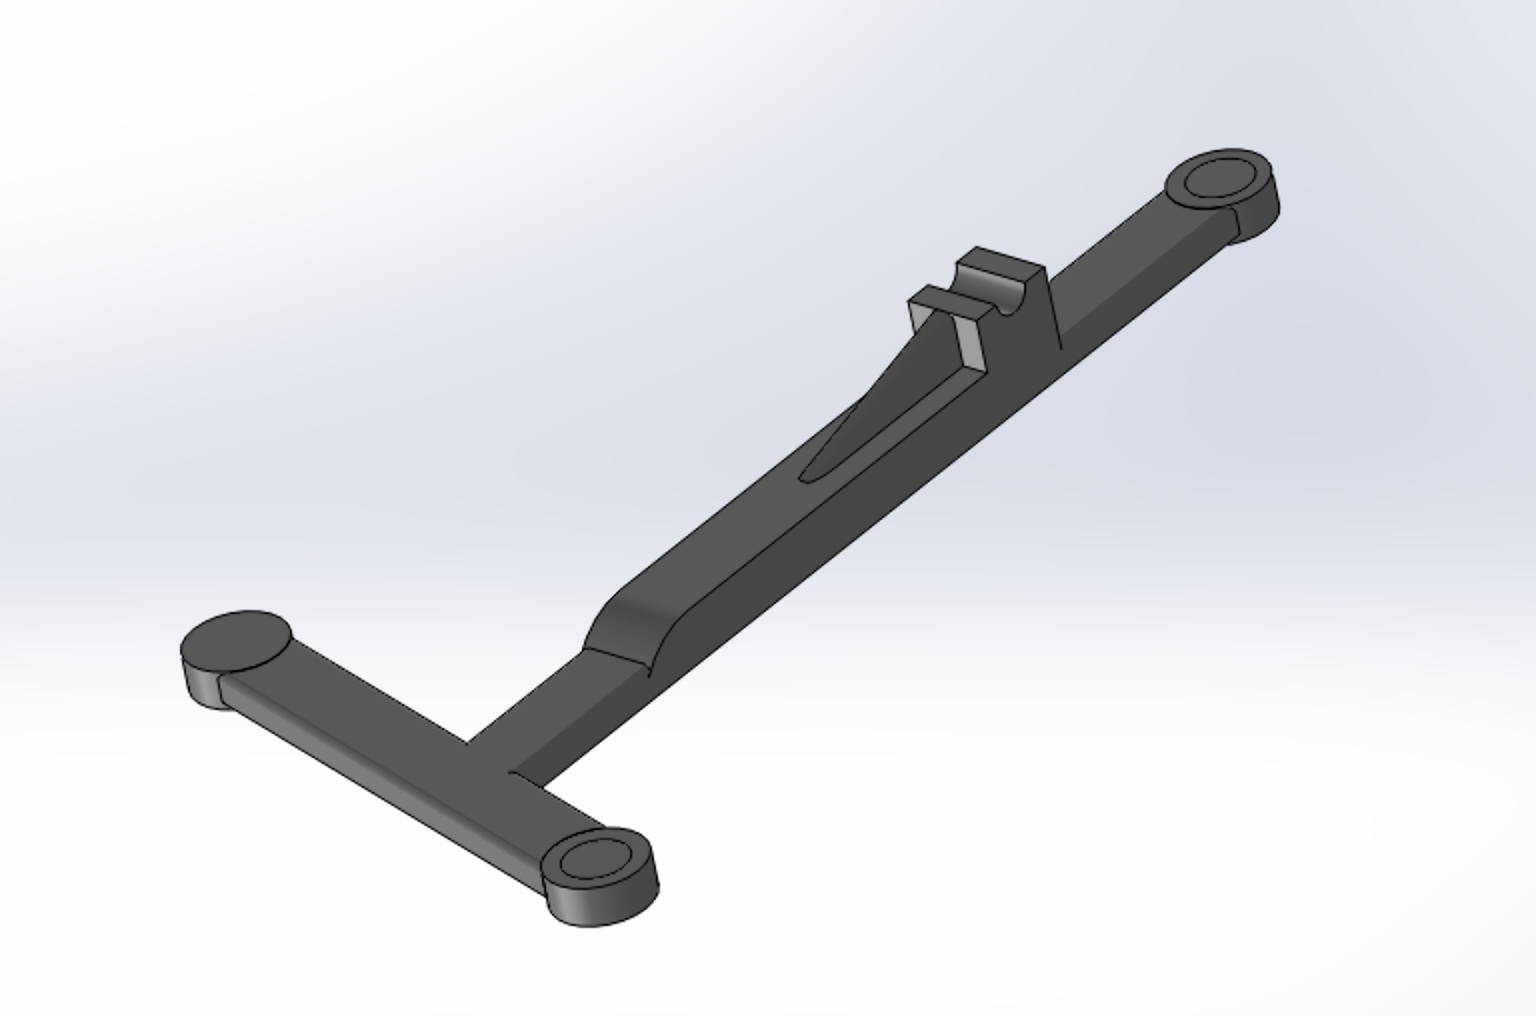

**Fig 6: FEA for Optimized Model of Foot**
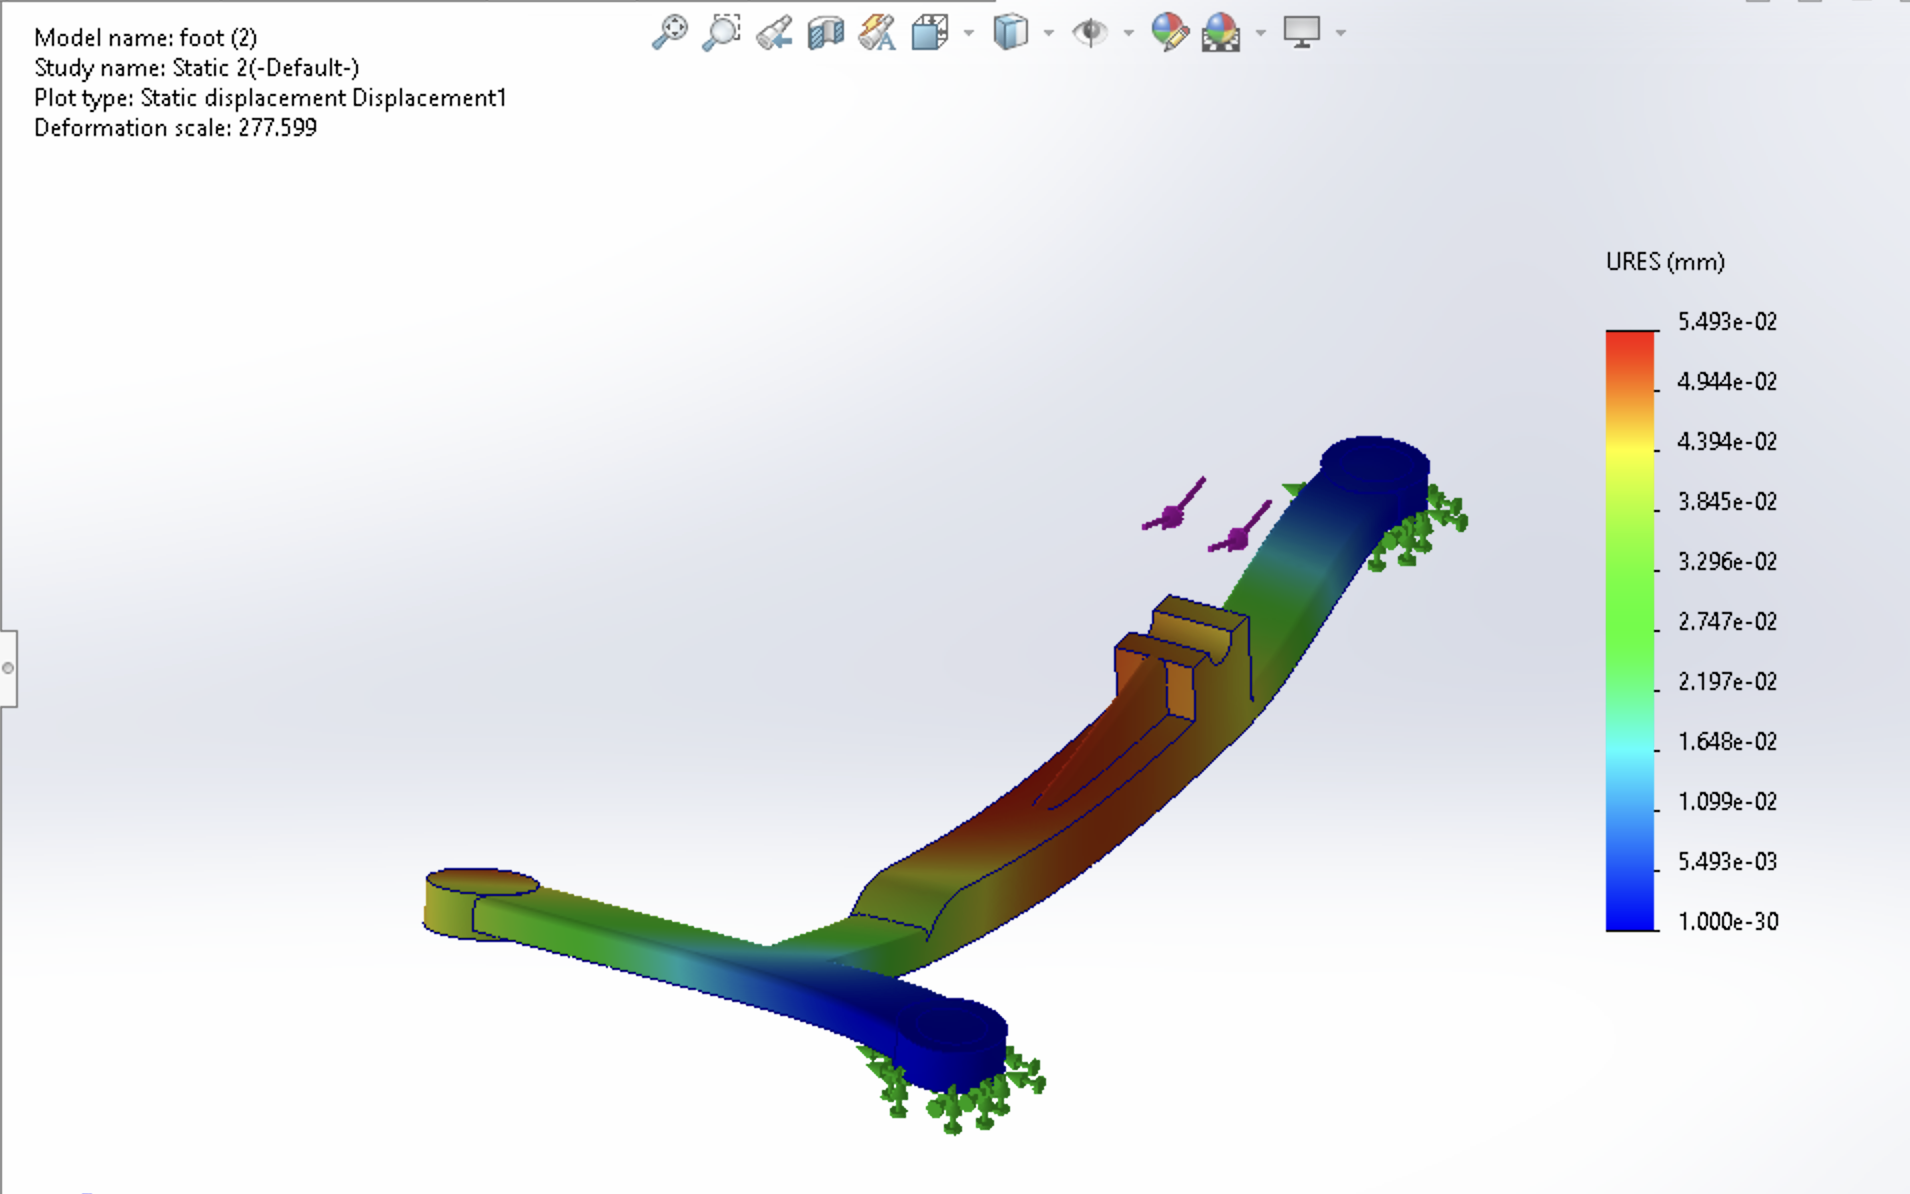

## Comparison of Results from the FEA and Hand Calculations

**This code calculates and compares the percent reduction in displacements at the big toe, ankle, and heel between the initial and optimized designs, presenting the results in a clear tabular format.**

In [ ]:
# Function to calculate percent reduction
def percentReduction(initial, optimized):
    """
    Calculate the percent reduction between initial and optimized values.
    Formula: ((initial - optimized) / initial) * 100
    """
    if initial == 0:
        return 0  # Avoid division by zero for zero initial displacement
    return ((initial - optimized) / initial) * 100

# Initial displacements (in mm)
initialToe = 0.000  # Big Toe
initialAnkle = 0.1404  # Ankle
initialHeel = 0.000  # Heel

# Optimized displacements (in mm)
optimizedToe = 0.000  # Big Toe
optimizedAnkle = 0.05493  # Ankle
optimizedHeel = 0.000  # Heel

# Calculate percent reductions
toeReduction = round(percentReduction(initialToe, optimizedToe), 2)
ankleReduction = round(percentReduction(initialAnkle, optimizedAnkle), 2)
heelReduction = round(percentReduction(initialHeel, optimizedHeel), 2)

# Display results in a table
print("Comparison of Displacements (Initial vs. Optimized):\n")
print(f"{'Location':<20} {'Initial (mm)':<15} {'Optimized (mm)':<15} {'Percent Reduction (%)':<20}")
print("-" * 60)
print(f"{'Big Toe':<20} {initialToe:<15} {optimizedToe:<15} {toeReduction:<20}")
print(f"{'Ankle':<20} {initialAnkle:<15} {optimizedAnkle:<15} {ankleReduction:<20}")
print(f"{'Heel':<20} {initialHeel:<15} {optimizedHeel:<15} {heelReduction:<20}")


Comparison of Displacements (Initial vs. Optimized):

Location             Initial (mm)    Optimized (mm)  Percent Reduction (%)
------------------------------------------------------------
Big Toe              0.0             0.0             0                   
Ankle                0.1404          0.05493         60.88               
Heel                 0.0             0.0             0                   
